# 2D example
This notebook shows a simple analysis pipeline for running and analyzing a 3D simulation with DISCO-DJ.

### Imports

In [1]:
# Import modules
import os
from matplotlib import pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("ticks")
import jax
from jax import config
import numpy as np
from discodj import DiscoDJ
plt.rcParams['image.cmap'] = "rocket"
print(jax.__version__)

0.7.2


In [2]:
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
#os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95" # maximize available memory (might need to tune this in case you're running out of memory)

### Simulation settings
DISCO-DJ can be run on a GPU (*much* faster) or on a CPU. The following cell detects if a GPU is available and sets the device accordingly.

In [3]:
# Detect if a GPU is available
devices = jax.devices()
device = "gpu" if np.any([d.platform == "gpu" for d in devices]) else "cpu"
print(device)

gpu


Now, we set the name of the analysis and the spatial dimension. The precision can be set to "single" (float32) or "double" (float64; in that case, the Jax config needs to be updated). DISCO-DJ is written in an class-based (yet functional) way, so you need to define a DiscoDJ object that will be used to perform all computations.

In [4]:
# Set the parameters
name = "2D_analysis"
dim = 2

precision = "double"
if precision == "double":
    config.update("jax_enable_x64", True)

# The cosmology can be provided as a dictionary or a string for a pre-defined cosmology (e.g. "CamelsCV" for the Camels Cosmic Variance suite).
# cosmo = "CamelsCV"
cosmo = dict(Omega_c=0.8,  # Einstein-de Sitter Universe with Omega_m = 1 (20% of which are assumed to be baryonic)
             Omega_b=0.2,
             Omega_k=0.0,
             h=0.6774,
             n_s=-1.9,
             sigma8=0.8,
             w0=-1.0,
             wa=0.0,
             mnu=0.0)

cosmo_nu = dict(Omega_c=0.8,  # Einstein-de Sitter Universe with Omega_m = 1 (20% of which are assumed to be baryonic)
             Omega_b=0.2,
             Omega_k=0.0,
             h=0.6774,
             n_s=-1.9,
             sigma8=0.8,
             w0=-1.0,
             wa=0.0,
             mnu = 0.06)

# Define the boxsize and resolution
boxsize = 1.0
res = 1024

# Define DISCO-DJ object
dj = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo)
dj_nu = DiscoDJ(dim=dim, res=res, name=name, device=device, precision=precision, boxsize=boxsize, cosmo=cosmo_nu)
print(dj)
print(dj_nu)

DiscoDJ
——————————
Name: 2D_analysis
Dimensions: 2D
Resolution: 1024² particles
Boxsize: 1.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.8000 
  Omega_b: 0.2000 
  Omega_de: -0.0001 
  h: 0.6774 
  n_s: -1.9000 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
DiscoDJ
——————————
Name: 2D_analysis
Dimensions: 2D
Resolution: 1024² particles
Boxsize: 1.0 Mpc/h
Precision: double
Device: gpu
Cosmology:
  Omega_c: 0.8000 
  Omega_b: 0.2000 
  Omega_de: -0.0015 
  h: 0.6774 
  n_s: -1.9000 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0600 


Next, we compute the timetable for the cosmological growth functions.

In [5]:
# Compute the linear power spectrum
dj = dj.with_timetables()
dj = dj.with_linear_ps(transfer_function="none") # "Eisenstein-Hu"

dj_nu = dj_nu.with_timetables()
dj_nu = dj_nu.with_linear_ps(transfer_function="none") # "Eisenstein-Hu"

In [6]:
cosmo = dj.cosmo
cosmo_nu = dj_nu.cosmo
print(cosmo)
print("#######################")
print(cosmo_nu)

  Omega_c: 0.8000 
  Omega_b: 0.2000 
  Omega_de: -0.0001 
  h: 0.6774 
  n_s: -1.9000 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0000 
#######################
  Omega_c: 0.8000 
  Omega_b: 0.2000 
  Omega_de: -0.0015 
  h: 0.6774 
  n_s: -1.9000 
  sigma8: 0.8000 
  Omega_k: 0.0000 
  w0: -1.0000 
  wa: 0.0000 
  mnu: 0.0600 


### Initial conditions

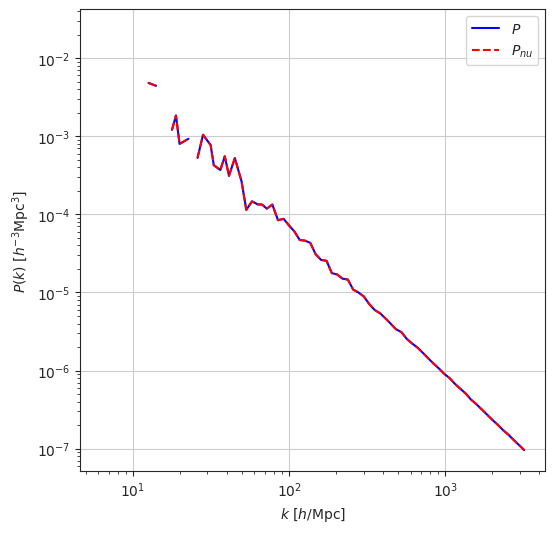

In [7]:
dj = dj.with_ics(seed=0, fix_std=0.9)
dj_nu = dj_nu.with_ics(seed=0, fix_std=0.9)

k_pre, Pk_pre, _ = dj.evaluate_power_spectrum(dj.delta_ini, compute_std=False, bins=80)
k_pre_nu, Pk_pre_nu, _ = dj_nu.evaluate_power_spectrum(dj_nu.delta_ini, compute_std=False, bins=80)
plt.figure(figsize=(6, 6))
plt.loglog(k_pre, Pk_pre, color='blue' , label=r'$P$')
plt.loglog(k_pre_nu, Pk_pre_nu , 'r--', label=r'$P_{nu}$')
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P(k)$ [$h^{-3}$Mpc$^3$]")
plt.legend()
plt.grid()
plt.show()

### Lagrangian perturbation theory (LPT)

In [8]:
n_order = 9
dj = dj.with_lpt(n_order=n_order, convert_to_numpy=True)
dj_nu = dj_nu.with_lpt(n_order=n_order, convert_to_numpy=True)

### Particle-mesh (PM) N-body simulation


In [9]:
a_ini = 0.0
a_end = 0.5
stepper = "bullfrog"
method = "pm"
res_pm = 2 * dj.res
time_var = "a"
antialias = 2
grad_kernel_order = 0
laplace_kernel_order = 0
n_resample = 16
deconvolve = True
n_steps = 4  # 4 time steps
nlpt_order_ics = n_order

In [10]:
X_sim, P_sim, a_sim = dj.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=n_steps, res_pm=res_pm, time_var=time_var,
                                   stepper=stepper, method=method, antialias=antialias,
                                   grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                   nlpt_order_ics=nlpt_order_ics, n_resample=n_resample, deconvolve=deconvolve)

X_sim_nu, P_sim_nu, a_sim_nu = dj_nu.run_nbody(a_ini=a_ini, a_end=a_end, n_steps=n_steps, res_pm=res_pm, time_var=time_var,
                                   stepper=stepper, method=method, antialias=antialias,
                                   grad_kernel_order=grad_kernel_order, laplace_kernel_order=laplace_kernel_order,
                                   nlpt_order_ics=nlpt_order_ics, n_resample=n_resample, deconvolve=deconvolve)

### Analysis

Let's compute the power spectrum:

In [11]:
delta_sim = dj.get_delta_from_pos(X_sim) #, res=2 * dj.res, n_resample=8
delta_sim_nu = dj_nu.get_delta_from_pos(X_sim_nu) #, res=2 * dj.res, n_resample=8

#print(delta_sim)
#print('#########')
#print(delta_sim_nu)

In [12]:
k, Pk, _ = dj.evaluate_power_spectrum(delta_sim, bins=dj.res//3, deconvolve=True, worder=2)
Pk_linear = dj.evaluate_linear_ps(a_end, k)  # linear expectation
_, Pk_linear_realized, _ = dj.evaluate_power_spectrum(dj.delta_ini, bins=dj.res//3)  # linear realization

k_nu, Pk_nu, _ = dj_nu.evaluate_power_spectrum(delta_sim_nu, bins=dj.res//3, deconvolve=True, worder=2)
Pk_linear_nu = dj_nu.evaluate_linear_ps(a_end, k)  # linear expectation
_, Pk_linear_realized_nu, _ = dj_nu.evaluate_power_spectrum(dj_nu.delta_ini, bins=dj.res//3)  # linear realization

#print(Pk)
#print("#######")
#print(Pk_nu)

Text(0.5, 1.0, 'Massive')

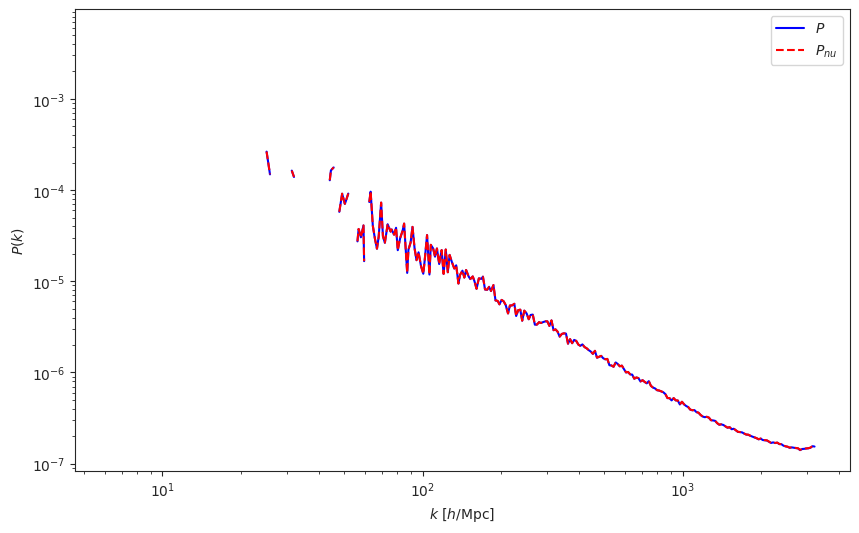

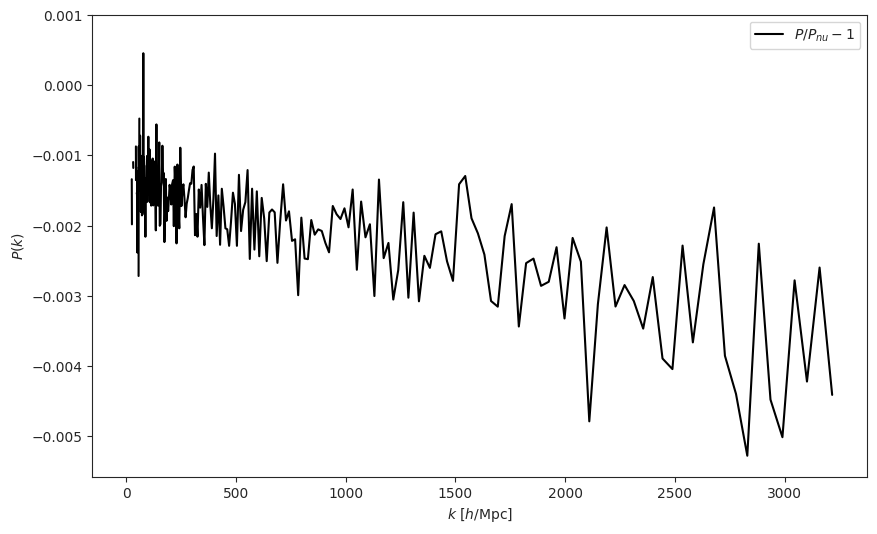

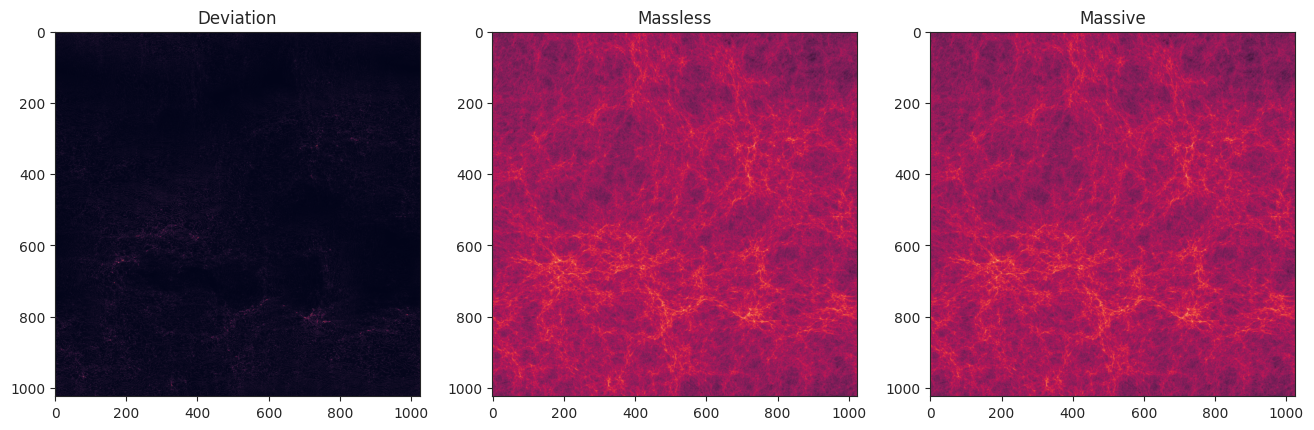

In [13]:
plt.figure(figsize=(10, 6))
plt.loglog(k, Pk,color='blue',label="$P$")
plt.loglog(k, Pk_nu,'r--',label="$P_{nu} $")
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P(k)$")
plt.legend(fontsize=10)

plt.figure(figsize=(10, 6))
plt.plot(k, Pk/Pk_nu -1, "k-", label="$P/P_{nu}-1$")
plt.xlabel(r"$k$ [$h$/Mpc]")
plt.ylabel(r"$P(k)$")
plt.legend(fontsize=10)

fig, axs = plt.subplots(1, 3, figsize=(16, 8))

axs[0].imshow(np.log10(1.1+ np.abs(delta_sim - delta_sim_nu)))
axs[0].set_title("Deviation")

axs[1].imshow(np.log10(1.1 + delta_sim))
axs[1].set_title("Massless")

axs[2].imshow(np.log10(1.1 + delta_sim_nu))
axs[2].set_title("Massive")